## Impl directories to analyze

In [1]:
from pathlib import Path

MODES = ["noDesign", "allAtOnce"] # , "allAtOnce", "byLayer"]
PROBLEM = "circuit_eval"

dirs = [
    Path(f"datasets/slopCodeBench/scb-problems/{PROBLEM}/implementations_{x}") for x in MODES
]
dirs

[PosixPath('datasets/slopCodeBench/scb-problems/circuit_eval/implementations_noDesign'),
 PosixPath('datasets/slopCodeBench/scb-problems/circuit_eval/implementations_allAtOnce')]

## Obtain overall metrics

In [2]:
import os 
from deterministic.write_metrics.write_overall_metrics import get_overall_metrics


# An array of arrays, each of length N 
# where N is the number of checkpoints of the problem 
data = [] 

for mode_no, mode in enumerate(MODES): 
    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 
    checkpoint_dirs.sort() 

    # walk through each checkpoint 
    mode_metrics = []  # metrics of all checkpoints, for a single mode 
    for i, checkpoint_name in enumerate(checkpoint_dirs): 
        impl_dir = dirs[mode_no] / checkpoint_name
        
        mode_metrics.append(
            get_overall_metrics(impl_dir) 
        )
    
    data.append(mode_metrics) 

print(data)

Module(loc=194, lloc=106, sloc=160, comments=0, multi=0, blank=34, single_comments=0)
Module(loc=208, lloc=130, sloc=174, comments=0, multi=0, blank=34, single_comments=0)
Module(loc=49, lloc=59, sloc=36, comments=0, multi=0, blank=13, single_comments=0)
Module(loc=68, lloc=40, sloc=40, comments=0, multi=0, blank=28, single_comments=0)
Module(loc=162, lloc=105, sloc=129, comments=1, multi=0, blank=32, single_comments=1)
Module(loc=194, lloc=106, sloc=160, comments=0, multi=0, blank=34, single_comments=0)
Module(loc=208, lloc=130, sloc=174, comments=0, multi=0, blank=34, single_comments=0)
Module(loc=49, lloc=59, sloc=36, comments=0, multi=0, blank=13, single_comments=0)
Module(loc=82, lloc=49, sloc=49, comments=0, multi=0, blank=33, single_comments=0)
Module(loc=246, lloc=163, sloc=201, comments=1, multi=0, blank=44, single_comments=1)
Module(loc=94, lloc=66, sloc=74, comments=0, multi=0, blank=20, single_comments=0)
Module(loc=318, lloc=177, sloc=267, comments=0, multi=0, blank=51, si

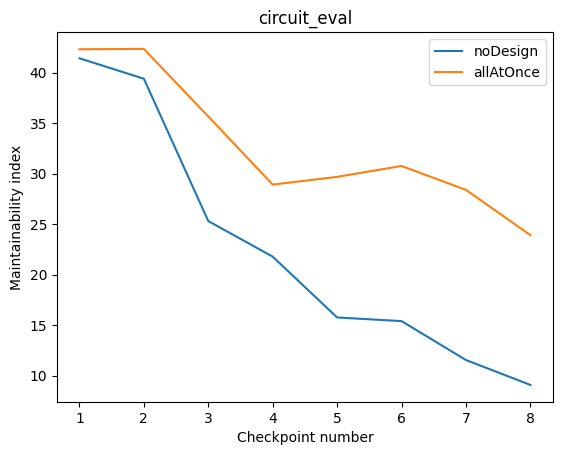

In [6]:
from matplotlib import pyplot as plt 

for i, entry in enumerate(data): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = [z["weighted_maintainability_index"] for z in entry]
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Maintainability index")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

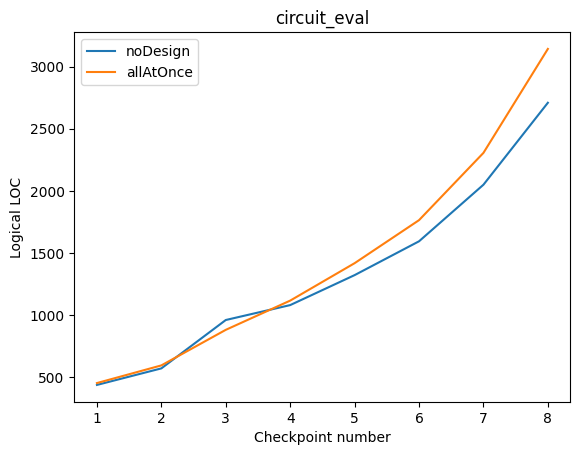

In [7]:
from matplotlib import pyplot as plt 

for i, entry in enumerate(data): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = [z["lloc"] for z in entry]
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Logical LOC")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

## For each of the directories generate temporary dirs for metrics

In [4]:
import subprocess 
import shutil 

for i, dir in enumerate(dirs):  
    subprocess.run([
        "scripts/metrics.sh", 
        dir, 
        f"temp_metrics/{modes[i]}"
    ], check=True)

[1/2] DPy metrics
invoking license validation...
DPy version 1.7.8 Trial
Copyright (c) Designite 2026.
Current Configuration:
  Input Path: /home/bernardmoy/modular-SWE/agent_workspace_noDesign/implementation
  Output Directory: /home/bernardmoy/modular-SWE/temp_metrics/noDesign/dpy_metrics
  Output Format: json
  Configuration File: /tmp/onefile_131520_1782941956_877571/default_config.json
  Log Directory: /home/bernardmoy/modular-SWE/temp_metrics/noDesign/dpy_metrics
invoking license validation...
License type: LicenseType.Trial
Parsing ...
Calculating metrics ...
Detecting code smells ...
Detecting design smells ...
Detecting architecture smells ...
Detecting machine learning smells ...
Collect dependencies ...
Analysis complete.
Preparing analysis summary ...
--Analysis summary--
	Total LOC analyzed: 755	Number of packages: 1
	Number of classes: 33	Number of modules: 1
	number of methods/functions: 67
-Total architecture smell instances detected-
	God component: 0	Unstable dependen

## Lines of code

In [10]:
import json 
from collections import defaultdict

for mode in modes: 
    # store modules: lines of code 
    d = defaultdict(int) 

    with open(f"temp_metrics/{mode}/dpy_metrics/implementation_function_metrics.json", 'r') as f: 
        function_metrics = json.load(f) 

        for f in function_metrics: 
            d[f["Module"]] += f["LOC"]
    
    print(json.dumps(d, indent=2))

{
  "circopt": 706
}
{
  "circopt_reporting": 46,
  "circopt_values": 67,
  "circopt_operator_semantics": 75,
  "circopt_model": 21,
  "circopt_evaluator": 41,
  "circopt_parser": 194,
  "circopt_input_binding": 32,
  "circopt": 2,
  "circopt_validator": 108,
  "circopt_cli": 165,
  "circopt_errors": 20
}
{
  "circ_parser": 194,
  "bit_values": 69,
  "circ_model": 27,
  "evaluator": 96,
  "commands": 14,
  "validator": 247,
  "runtime_inputs": 28,
  "circopt": 2,
  "errors": 7,
  "output": 55,
  "cli": 119
}


## Cyclomatic complexity

In [12]:
for mode in modes: 
    # store modules: lines of code 
    function_total = 0 
    cc_5 = 0 
    cc_10 = 0 

    with open(f"temp_metrics/{mode}/dpy_metrics/implementation_function_metrics.json", 'r') as f: 
        function_metrics = json.load(f) 

        function_total = len(function_metrics) 
        for f in function_metrics: 
            if f["CC"] >= 5: 
                cc_5 += 1 
            if f["CC"] >= 10: 
                cc_10 += 1 
        
        print(f"""Total no. of functions: {function_total} 
No. of functions CC>=5: {cc_5} 
No. of functions CC>=10: {cc_10}
""")

Total no. of functions: 67 
No. of functions CC>=5: 11 
No. of functions CC>=10: 2

Total no. of functions: 88 
No. of functions CC>=5: 8 
No. of functions CC>=10: 0

Total no. of functions: 93 
No. of functions CC>=5: 7 
No. of functions CC>=10: 0



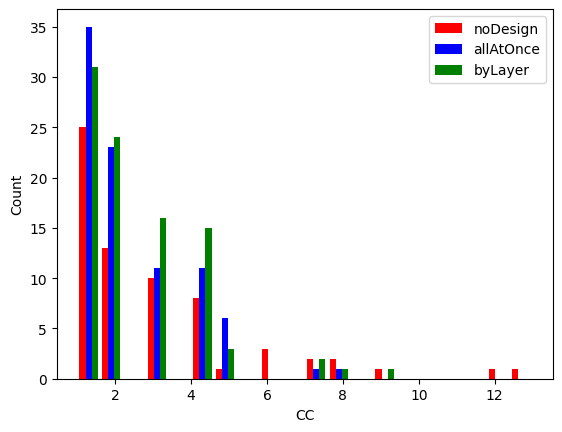

In [17]:
# Histogram of CC 
import matplotlib.pyplot as plt 

data = [] 
for mode in modes: 
    with open(f"temp_metrics/{mode}/dpy_metrics/implementation_function_metrics.json", 'r') as f: 
        function_metrics = json.load(f) 

        data.append(
            [x["CC"] for x in function_metrics]
        )

plt.hist(
    data,
    bins=20,
    label=modes,
    color=["red", "blue", "green"]
)

plt.legend()
plt.xlabel("CC")
plt.ylabel("Count")
plt.show()